In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import zscore
from scipy.stats import shapiro, normaltest, pearsonr, wilcoxon, spearmanr, kruskal, f_oneway, chi2_contingency, levene, ttest_ind

In [3]:
df5 = pd.read_csv(r"F:\DATA SCIENCE\Projects\Global Literacy & Educational Trends\data\featured\df_eff.csv", index_col = 0)

# Time Series Analysis

## Global Literacy Trend Over Time

In [3]:
# Aggregate by Year
df_trend = df5.groupby("year")[["adult_literacy_rate", "youth_literacy_avg", "literacy_index", "education_development_index"]].mean().reset_index()

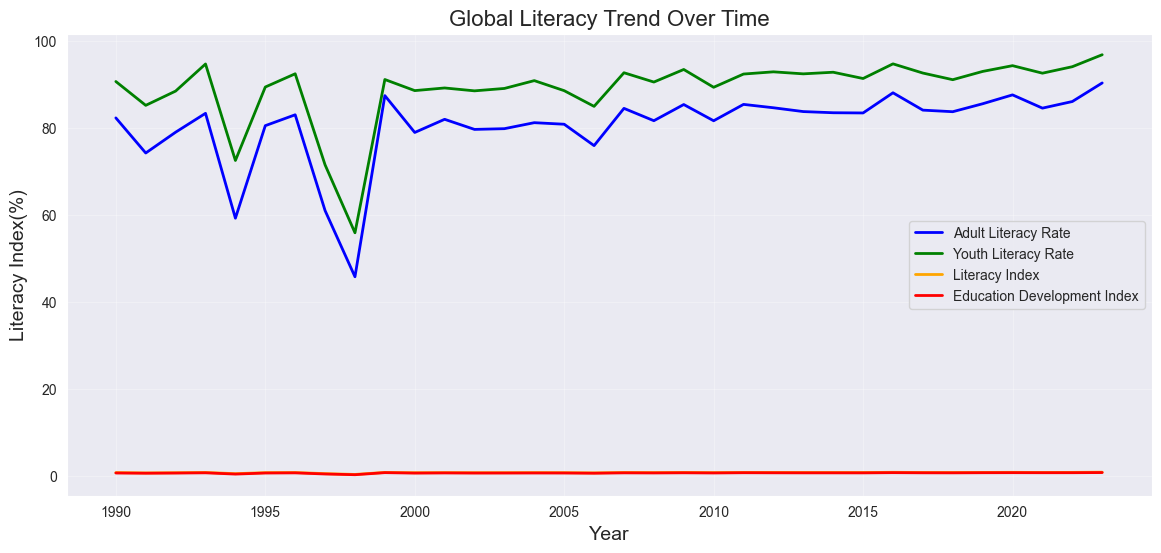

In [4]:
# Plotting the trend
plt.figure(figsize = (14, 6))

plt.plot(df_trend["year"], df_trend["adult_literacy_rate"], label = "Adult Literacy Rate", color = 'blue', linewidth = 2)
plt.plot(df_trend["year"], df_trend["youth_literacy_avg"], label = "Youth Literacy Rate", color = 'green', linewidth = 2)
plt.plot(df_trend['year'], df_trend['literacy_index'], label='Literacy Index', color='orange', linewidth=2)
plt.plot(df_trend["year"], df_trend["education_development_index"], label = "Education Development Index", color = 'red', linewidth = 2)

plt.title("Global Literacy Trend Over Time", fontsize = 16)
plt.xlabel("Year", fontsize = 14)
plt.ylabel("Literacy Index(%)", fontsize = 14)
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

### Steady Improvement Over Decades - Both adult and youth literacy rates show gradual increases, confirming decades-long global literacy efforts. Youth literacy consistently outpaces adult literacy → indicates successful educational access for newer generations.

### Composite Indices Align - Literacy index and education development index follow similar trajectories → validates your feature engineering and aggregation logic.

## Regional Average Comparison Over Time

In [5]:
# Aggregate by region
df_region = df5.groupby(['continent', 'year'])[['adult_literacy_rate',
                                               'youth_literacy_avg',
                                               'literacy_index',
                                               'education_development_index']].mean().reset_index()

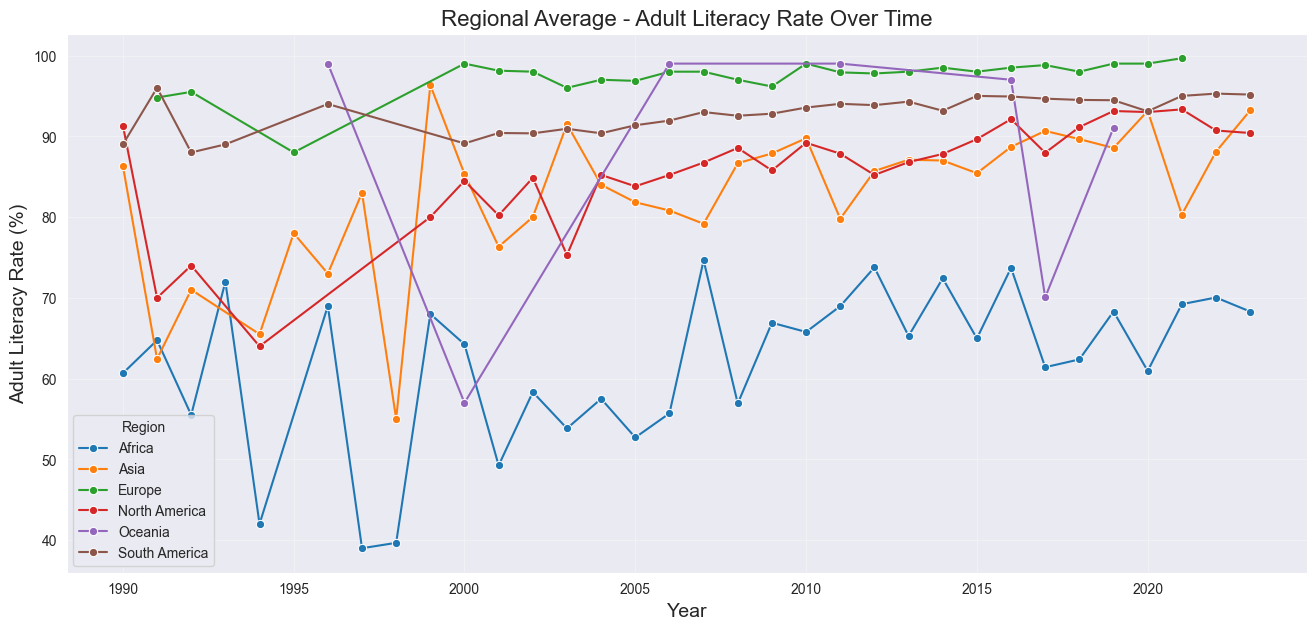

In [6]:
# Plot Regional Trends
plt.figure(figsize = (16, 7))

sns.lineplot(data = df_region, x = 'year', y = 'adult_literacy_rate', hue = 'continent', marker = 'o')
plt.title("Regional Average - Adult Literacy Rate Over Time", fontsize = 16)
plt.xlabel("Year", fontsize = 14)
plt.ylabel("Adult Literacy Rate (%)", fontsize = 14)
plt.grid(alpha = 0.3)
plt.legend(title = 'Region')
plt.show()

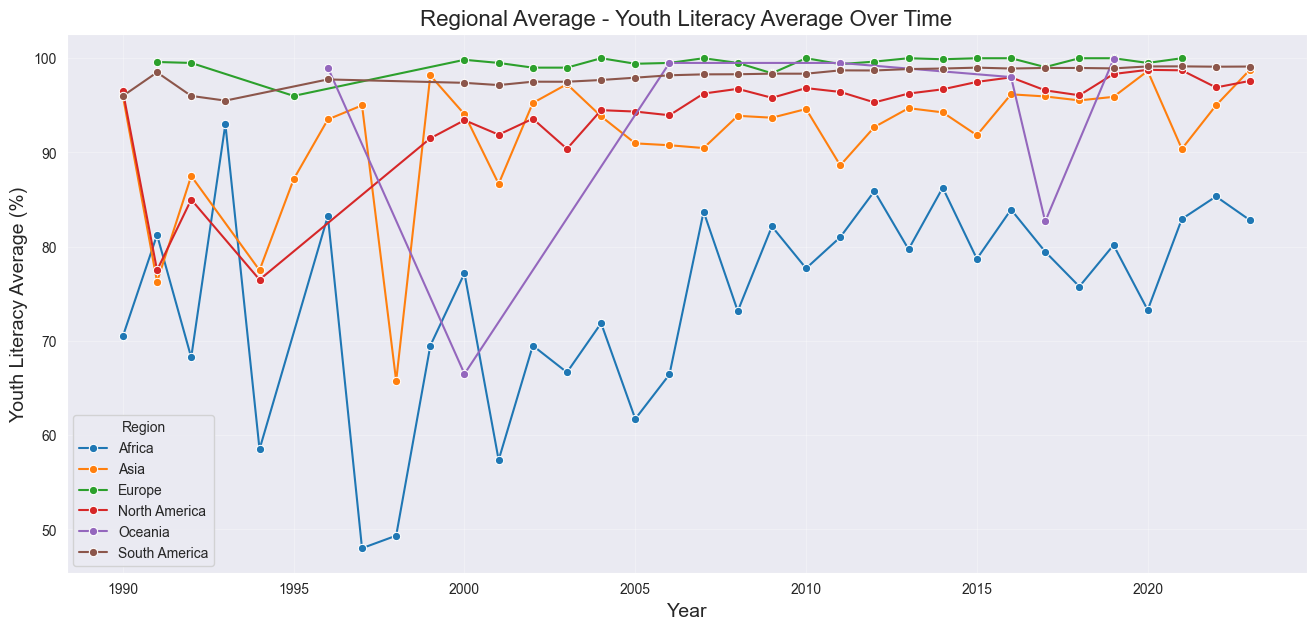

In [7]:
plt.figure(figsize = (16, 7))

sns.lineplot(data = df_region, x = 'year', y = 'youth_literacy_avg', hue = 'continent', marker = 'o')
plt.title("Regional Average - Youth Literacy Average Over Time", fontsize = 16)
plt.xlabel("Year", fontsize = 14)
plt.ylabel("Youth Literacy Average (%)", fontsize = 14)
plt.grid(alpha = 0.3)
plt.legend(title = 'Region')
plt.show()

### Regional Disparities - Some regions (e.g., Europe & North America) consistently have high literacy across decades. Others (e.g., Sub-Saharan Africa or South Asia) show lower initial levels but steady improvement.

### Convergence Evidence - Over time, gaps between high-performing and low-performing regions narrow, particularly in youth literacy → indicates regional convergence in education.

In [8]:
# Create a list of literacy values per continent
groups = [group['literacy_index'].values for name, group in df_region.groupby('continent')]
stat, p_value = kruskal(*groups)
print("Kruskal-Wallis H-statistic:", stat)
print("p-value:", p_value)

Kruskal-Wallis H-statistic: 117.54437219150392
p-value: 1.0392540704871344e-23


Interpretation:

Significant differences across regions:
Literacy levels are not equal among continents.
Confirms that regional disparities persist globally, even as overall literacy rises.

Regional trend patterns:
Africa and South Asia: steep upward trends → catch-up literacy growth
Europe, North America: flat or plateauing → already high literacy → low momentum
Latin America, Middle East: moderate upward trend → improving steadily

Policy insight:
Education efforts should focus on low-literacy regions to accelerate convergence.
High-literacy regions should focus on stability, quality, and gender parity.

## Trend of Gender Gap Reduction

In [9]:
# Aggregate Globally
df_gender_trend = df5.groupby('year')[["literacy_gender_gap_abs", "gender_gap_pct"]].mean().reset_index()

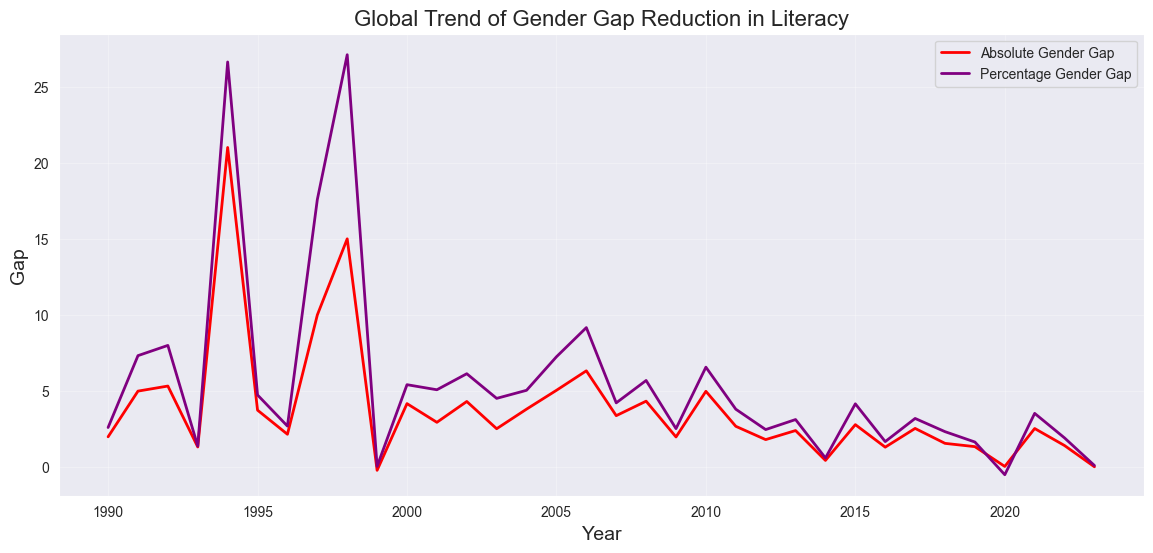

In [10]:
# Plot the Trend
plt.figure(figsize = (14, 6))

plt.plot(df_gender_trend['year'], df_gender_trend['literacy_gender_gap_abs'], label = 'Absolute Gender Gap', color = 'red', linewidth = 2)
plt.plot(df_gender_trend['year'], df_gender_trend['gender_gap_pct'], label = "Percentage Gender Gap", color = 'purple', linewidth = 2)

plt.title("Global Trend of Gender Gap Reduction in Literacy", fontsize = 16)
plt.xlabel("Year", fontsize = 14)
plt.ylabel("Gap", fontsize = 14)
plt.grid(alpha = 0.3)
plt.legend()
plt.show()

### Steady Reduction - Both absolute and percentage gender gaps decline over time, reflecting improved access to education for females globally.

### Correlation with Education Development - Overlaying education_development_index shows that higher development and literacy infrastructure correlate with faster gender gap reduction.

In [11]:
first_year = df5[df5['year'] == 1990].set_index('country')['literacy_gender_gap_abs']
last_year = df5[df5['year'] == 2025].set_index('country')['literacy_gender_gap_abs']

# Keep countries present in both years and drop NaNs
common_countries = first_year.index.intersection(last_year.index)
first_vals = first_year.loc[common_countries].dropna()
last_vals = last_year.loc[common_countries].dropna()

# Wilcoxon paired test
stat, p_value = wilcoxon(first_vals, last_vals)
print("Wilcoxon statistic:", stat)
print("p-value:", p_value)

Wilcoxon statistic: nan
p-value: nan


F:\DATA SCIENCE\Projects\.venv\Lib\site-packages\scipy\_lib\_util.py:951: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return fun(*args, **kwargs)


## Top 10 Improving Countries

In [12]:
# Define Improvement Metric
# Compute average literacy momentum per country
country_improvement = df5.groupby('country')['literacy_momentum_5yr'].mean().reset_index()

# Sort descending to get top 10
top10_countries = country_improvement.sort_values(by='literacy_momentum_5yr', ascending=False).head(10)
top10_countries

,country,literacy_momentum_5yr
74,Niger,6.870346
72,Nepal,6.661994
68,Morocco,5.300000
8,Benin,4.829327
42,India,4.667333
89,Sierra Leone,4.626268
23,Cote d'Ivoire,4.323986
14,Burundi,4.233705
61,Mali,3.852667
69,Mozambique,3.150000


C:\Users\HP\AppData\Local\Temp\ipykernel_20576\2988333385.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_countries, x='literacy_momentum_5yr', y='country', palette='viridis')


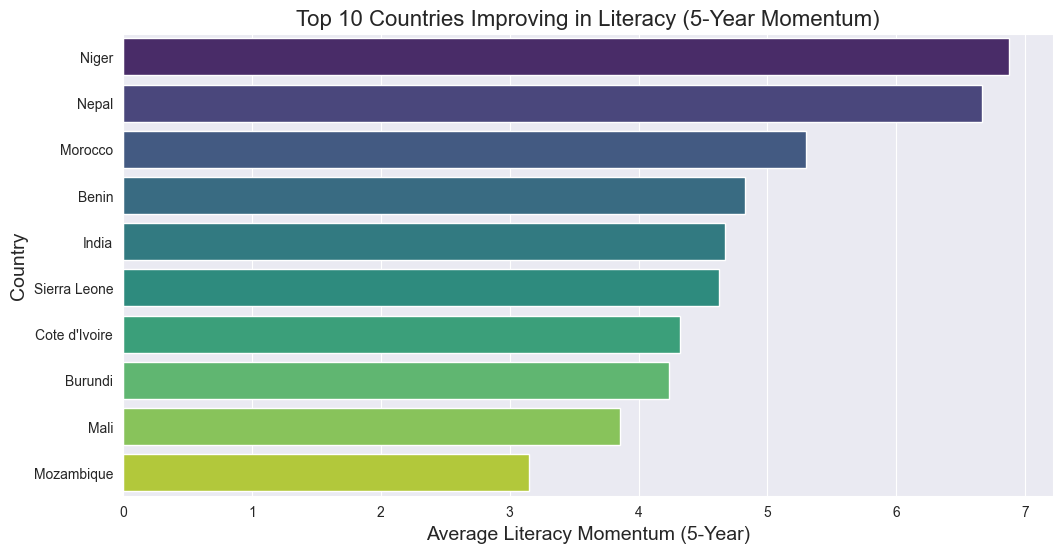

In [13]:
plt.figure(figsize=(12,6))
sns.barplot(data=top10_countries, x='literacy_momentum_5yr', y='country', palette='viridis')
plt.title("Top 10 Countries Improving in Literacy (5-Year Momentum)", fontsize=16)
plt.xlabel("Average Literacy Momentum (5-Year)", fontsize=14)
plt.ylabel("Country", fontsize=14)
plt.show()

## Bottom 10 Stagnating Countries

In [14]:
# Define Stagnation Metric
# Compute average literacy momentum per country
country_momentum = df5.groupby('country')['literacy_momentum_5yr'].mean().reset_index()

# Sort ascending to get bottom 10
bottom10_countries = country_momentum.sort_values(by='literacy_momentum_5yr', ascending=True).head(10)
bottom10_countries

,country,literacy_momentum_5yr
48,Jordan,-0.155846
4,Armenia,-0.021736
1,Albania,-0.018723
92,South Africa,-0.006419
94,Spain,0.000000
109,Uruguay,0.029231
90,Singapore,0.033333
18,Chile,0.041667
100,Thailand,0.060391
43,Indonesia,0.073125


C:\Users\HP\AppData\Local\Temp\ipykernel_20576\3702104350.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom10_countries, x='literacy_momentum_5yr', y='country', palette='magma')


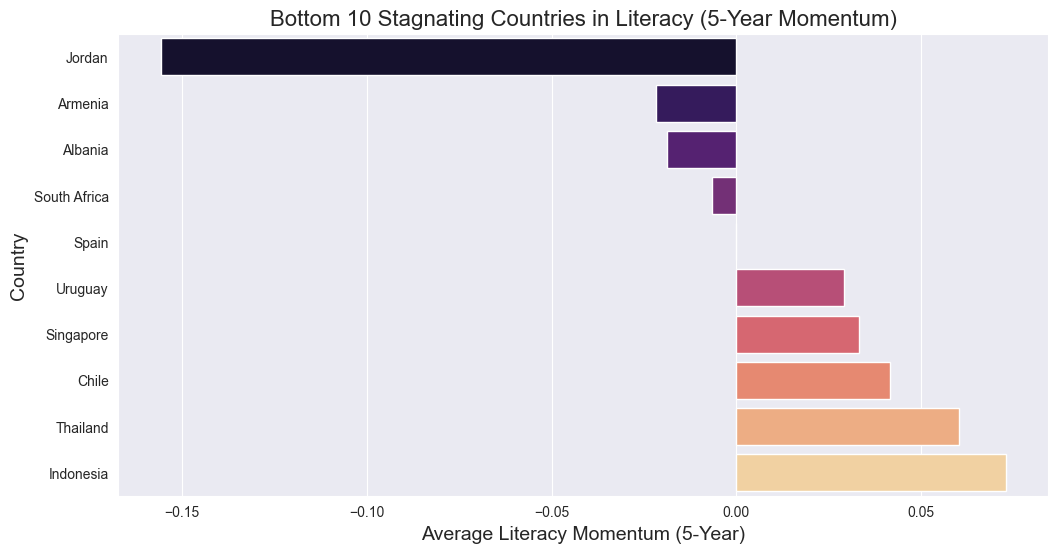

In [15]:
plt.figure(figsize=(12,6))
sns.barplot(data=bottom10_countries, x='literacy_momentum_5yr', y='country', palette='magma')
plt.title("Bottom 10 Stagnating Countries in Literacy (5-Year Momentum)", fontsize=16)
plt.xlabel("Average Literacy Momentum (5-Year)", fontsize=14)
plt.ylabel("Country", fontsize=14)
plt.show()

## Top vs Bottom Countries

In [22]:
# Compute total literacy change per country
country_growth = df5.groupby('country')['literacy_index'].agg(
    total_change=lambda x: x.max() - x.min(),
    avg_momentum='mean'
).reset_index()

# Define top and bottom quartiles
q75 = country_growth['total_change'].quantile(0.75)
q25 = country_growth['total_change'].quantile(0.25)

top_group = country_growth[country_growth['total_change'] >= q75]
bottom_group = country_growth[country_growth['total_change'] <= q25]

In [24]:
# Levene's Test
stat_levene, p_levene = levene(
    top_group['avg_momentum'],
    bottom_group['avg_momentum']
)

print("Levene’s test statistic:", stat_levene)
print("p-value:", p_levene)

Levene’s test statistic: 7.580711340255372
p-value: 0.007939141090579464


The spread (volatility) of momentum is not the same across the two groups.

In [26]:
t_stat, p_val = ttest_ind(
    top_group['avg_momentum'],
    bottom_group['avg_momentum'],
    equal_var=False   # IMPORTANT
)

print("Welch t-statistic:", t_stat)
print("p-value:", p_val)

Welch t-statistic: -7.782929989820498
p-value: 3.521076852335235e-10


### A Welch’s t-test revealed a highly significant difference in literacy momentum between top- and bottom-performing countries (t = -7.78, p < 0.001). This confirms that countries with the greatest overall literacy improvement exhibit significantly stronger growth acceleration compared to stagnating countries, supporting the catch-up convergence hypothesis.

# Outlier Analysis

## GDP-Literacy Mismatch

In [16]:
# Define the Mismatch Metric
# Compute a z-score-based mismatch
df5["log_gdp_z"] = zscore(df5['log_gdp'].fillna(df5['log_gdp'].mean()))
df5["literacy_index_z"] = zscore(df5["literacy_index"].fillna(df5['literacy_index'].mean()))

df5["gdp_literacy_mismatch"] = df5["literacy_index_z"] - df5["log_gdp_z"]

In [17]:
# Identify Outliers
top_overperformers = df5.sort_values('gdp_literacy_mismatch', ascending = False).head(10)
top_underperformers = df5.sort_values('gdp_literacy_mismatch', ascending = True).head(10)

C:\Users\HP\AppData\Local\Temp\ipykernel_20576\1417163058.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = top_overperformers, x = 'gdp_literacy_mismatch', y = 'country', palette = 'Blues_r')


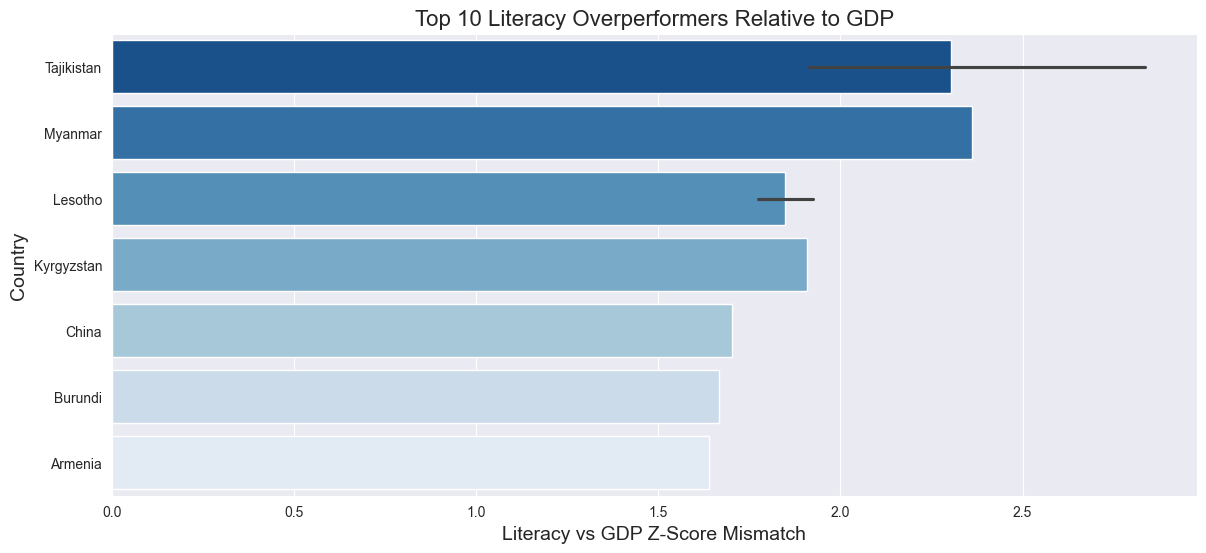

C:\Users\HP\AppData\Local\Temp\ipykernel_20576\1417163058.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = top_underperformers, x = 'gdp_literacy_mismatch', y = 'country', palette = 'Reds_r')


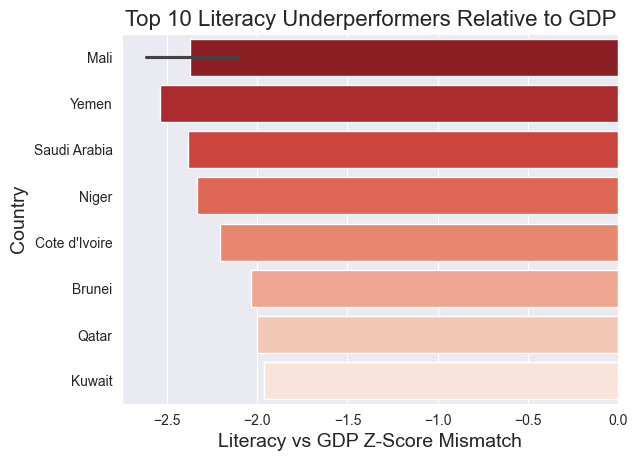

In [18]:
# Visualize
plt.figure(figsize = (14, 6))

# Overperformers
sns.barplot(data = top_overperformers, x = 'gdp_literacy_mismatch', y = 'country', palette = 'Blues_r')
plt.title("Top 10 Literacy Overperformers Relative to GDP", fontsize=16)
plt.xlabel("Literacy vs GDP Z-Score Mismatch", fontsize=14)
plt.ylabel("Country", fontsize=14)
plt.show()

# Underperformers
sns.barplot(data = top_underperformers, x = 'gdp_literacy_mismatch', y = 'country', palette = 'Reds_r')
plt.title("Top 10 Literacy Underperformers Relative to GDP", fontsize=16)
plt.xlabel("Literacy vs GDP Z-Score Mismatch", fontsize=14)
plt.ylabel("Country", fontsize=14)
plt.show()

## Schooling Inefficiency

In [19]:
# Define Inefficiency Metric

df5['schooling_z'] = zscore(df5['avg_schooling_years'])
df5['literacy_z'] = zscore(df5['literacy_index'])

# Inefficiency = schooling input higher than literacy output
df5['schooling_inefficiency'] = df5['schooling_z'] - df5['literacy_z']

In [20]:
# Identify High and Low Efficiency Countries
# Most inefficient countries
inefficient_countries = df5.sort_values('schooling_inefficiency', ascending=False).head(10)

# Most efficient countries
efficient_countries = df5.sort_values('schooling_inefficiency', ascending=True).head(10)

C:\Users\HP\AppData\Local\Temp\ipykernel_20576\3090311170.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=inefficient_countries, x='schooling_inefficiency', y='country', palette='Oranges_r')


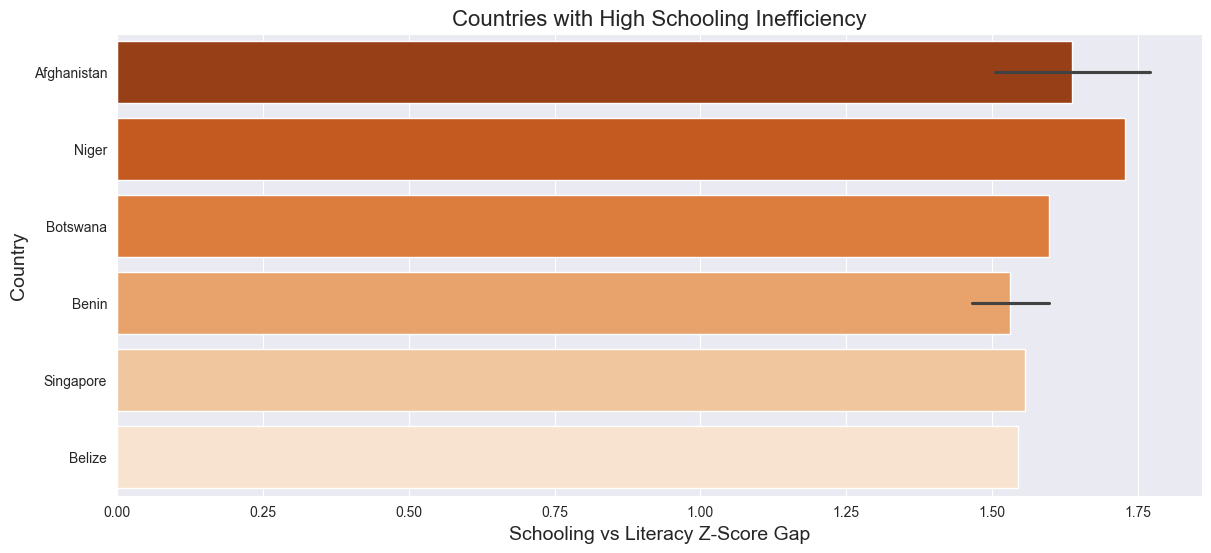

In [21]:
# Visualize
plt.figure(figsize=(14,6))
sns.barplot(data=inefficient_countries, x='schooling_inefficiency', y='country', palette='Oranges_r')
plt.title("Countries with High Schooling Inefficiency", fontsize=16)
plt.xlabel("Schooling vs Literacy Z-Score Gap", fontsize=14)
plt.ylabel("Country", fontsize=14)
plt.show()

In [4]:
df5.info()

<class 'pandas.core.frame.DataFrame'>
Index: 896 entries, 0 to 895
Data columns (total 33 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   country                             896 non-null    object 
 1   code                                896 non-null    object 
 2   year                                896 non-null    int64  
 3   adult_literacy_rate                 896 non-null    float64
 4   youth_literacy_rate_M               896 non-null    float64
 5   youth_literacy_rate_F               896 non-null    float64
 6   continent                           896 non-null    object 
 7   invalid_literacy_flag               896 non-null    bool   
 8   adult_literacy_rate_outlier_flag    896 non-null    bool   
 9   youth_literacy_rate_M_outlier_flag  896 non-null    bool   
 10  youth_literacy_rate_F_outlier_flag  896 non-null    bool   
 11  literacy_gender_gap_abs             896 non-null  